In [1]:
import pandas as pd
from sklearn.datasets import load_digits
digits = load_digits()

In [3]:
X = pd.DataFrame(digits.data, columns=digits.feature_names)
y = digits.target

display(X.head())

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 1437
Testing set size: 360


In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

print("KNN model trained successfully!")

KNN model trained successfully!


In [6]:
y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy of the KNN model: {accuracy:.4f}")

Accuracy of the KNN model: 0.9861


In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 11) # Testing k from 1 to 10

accuracies = []

print("Evaluating KNN models with different K values...")

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)

    knn_model.fit(X_train, y_train)

    y_pred_k = knn_model.predict(X_test)

    accuracy_k = accuracy_score(y_test, y_pred_k)
    accuracies.append(accuracy_k)
    print(f"K = {k}: Accuracy = {accuracy_k:.4f}")

best_k_index = accuracies.index(max(accuracies))
best_k = k_values[best_k_index]
best_accuracy = accuracies[best_k_index]

print(f"\nBest K value found: {best_k} with an accuracy of {best_accuracy:.4f}")

Evaluating KNN models with different K values...
K = 1: Accuracy = 0.9778
K = 2: Accuracy = 0.9806
K = 3: Accuracy = 0.9833
K = 4: Accuracy = 0.9806
K = 5: Accuracy = 0.9861
K = 6: Accuracy = 0.9889
K = 7: Accuracy = 0.9889
K = 8: Accuracy = 0.9861
K = 9: Accuracy = 0.9806
K = 10: Accuracy = 0.9833

Best K value found: 6 with an accuracy of 0.9889


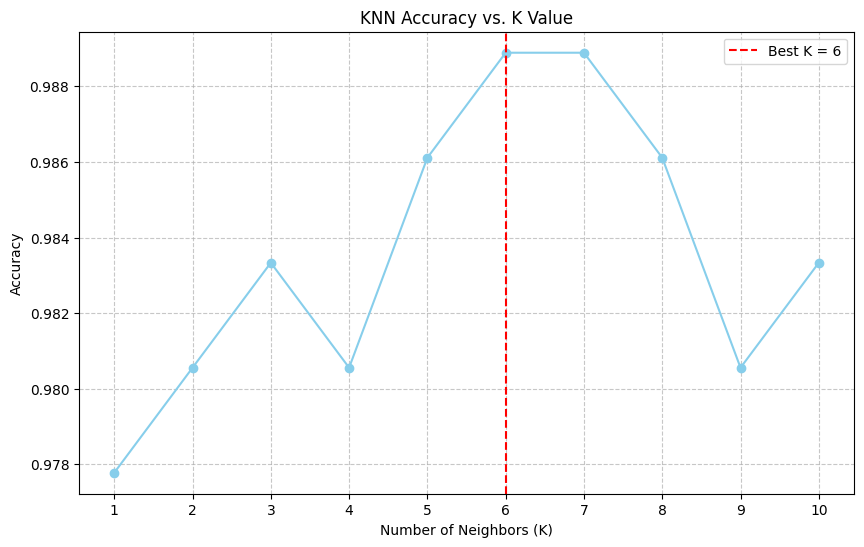

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='skyblue')
plt.title('KNN Accuracy vs. K Value')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.7)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.legend()
plt.show()